<a href="https://colab.research.google.com/github/AndrBoch/University/blob/main/tasks/Module_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №3. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [ ]:
# Ваш код

2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [ ]:
!wget https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
!wget https://github.com/opengeos/datasets/releases/download/raster/cog.tif

--2026-03-12 21:18:12--  https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/772999364/190f4060-f10b-4a8b-8b47-a66fdfd02d19?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-12T22%3A10%3A48Z&rscd=attachment%3B+filename%3Ddem_90m.tif&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-12T21%3A10%3A04Z&ske=2026-03-12T22%3A10%3A48Z&sks=b&skv=2018-11-09&sig=uofJMOaQt5Mc9%2FK4AKjuZO7zJF3Wjsgso51Bzy%2BmrAI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzM1MjA5MiwibmJmIjoxNzczMzUwMjkyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNv

3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [ ]:
import rasterio
from rasterio.plot import show
from rasterio.windows import Window
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import numpy as np

def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm

dem_path = "dem_90m.tif"
with rasterio.open(dem_path) as dem:
    print("Метаданные DEM:")
    print(dem.meta)

    width = dem.width
    height = dem.height
    count = dem.count
    dtype = dem.dtypes[0]
    bounds = dem.bounds
    crs = dem.crs

    print(f"Ширина: {width}, Высота: {height}")
    print(f"Количество каналов: {count}")
    print(f"Тип данных: {dtype}")
    print(f"Границы: {bounds}")
    print(f"Система координат: {crs}")

Метаданные DEM:
{'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 4269, 'height': 3113, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(90.0, 0.0, -13442488.3428,
       0.0, -89.99579177642138, 4668371.5775)}
Ширина: 4269, Высота: 3113
Количество каналов: 1
Тип данных: int16
Границы: BoundingBox

---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


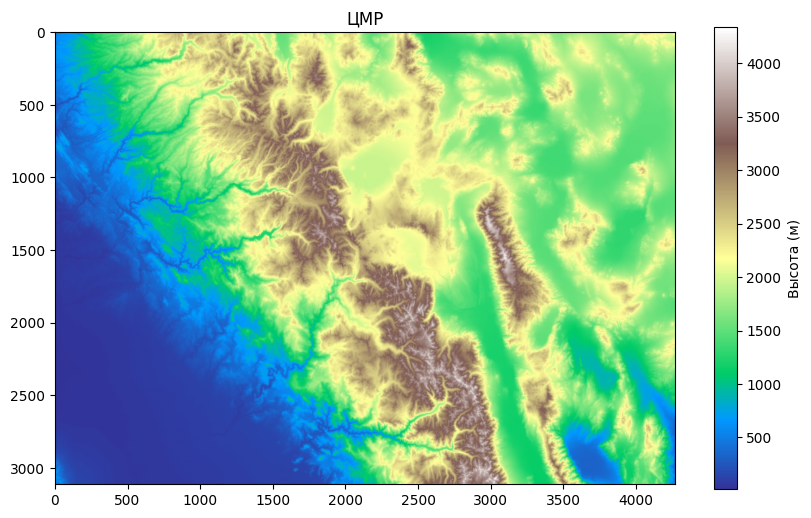

In [ ]:
with rasterio.open(dem_path) as dem:
    dem_array = dem.read(1)
    plt.figure(figsize=(10,6))
    plt.title("ЦМР")
    plt.imshow(dem_array, cmap='terrain')
    plt.colorbar(label='Высота (м)')
    plt.show()

2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


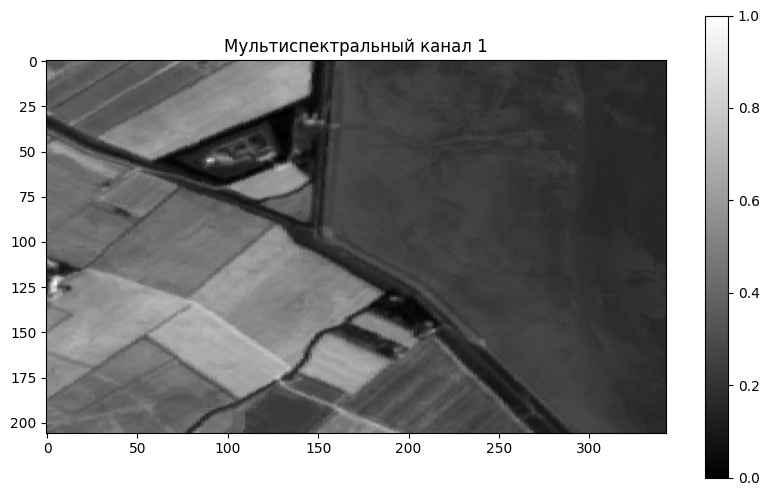

In [ ]:
ms_path = "cog.tif"
with rasterio.open(ms_path) as ms:
    band1 = ms.read(1)
    plt.figure(figsize=(10,6))
    plt.title("Мультиспектральный канал 1")
    plt.imshow(normalize(band1), cmap='gray')
    plt.colorbar()
    plt.show()

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

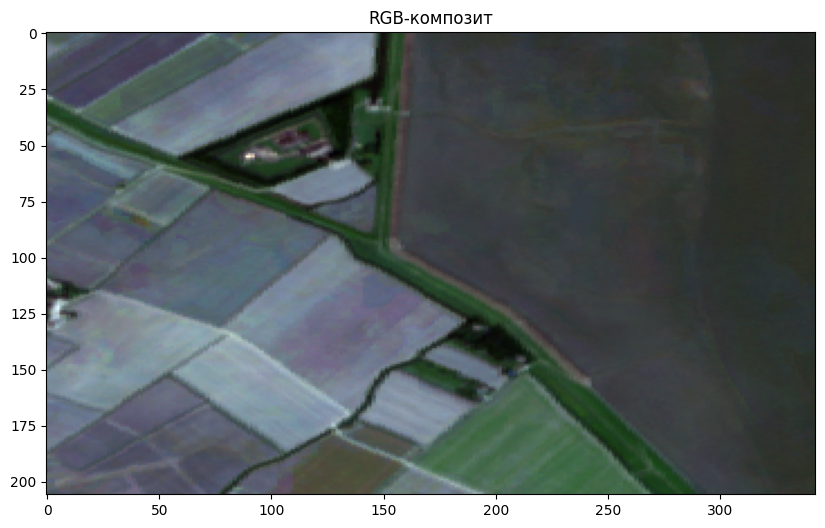

In [ ]:
with rasterio.open(ms_path) as ms:
  red = normalize(ms.read(3))
  green = normalize(ms.read(2))
  blue = normalize(ms.read(1))
  rgb = np.dstack((red, green, blue))

  plt.figure(figsize=(10,6))
  plt.title("RGB-композит")
  plt.imshow(rgb)
  plt.show()

---



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

In [ ]:
# Ваш код

3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

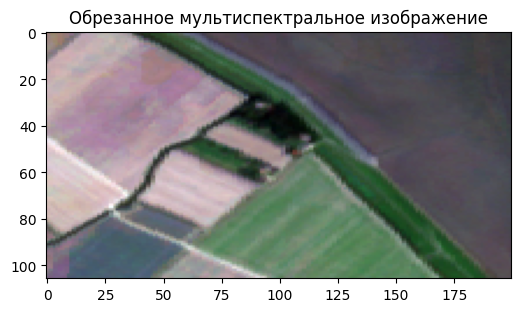

In [ ]:
with rasterio.open(ms_path) as ms:
    row_start, row_end = 100, 300
    col_start, col_end = 100, 300
    window = Window(col_start, row_start, col_end - col_start, row_end - row_start)

    clipped = ms.read(window=window)

    clipped_norm = np.stack([normalize(clipped[i]) for i in range(clipped.shape[0])], axis=-1)

    plt.figure(figsize=(6,6))
    plt.title("Обрезанное мультиспектральное изображение")
    plt.imshow(clipped_norm[:, :, :3])
    plt.show()

    out_meta = ms.meta.copy()
    out_meta.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": rasterio.windows.transform(window, ms.transform)
    })

    with rasterio.open("clipped_multispectral.tif", "w", **out_meta) as dest:
        dest.write(clipped)

---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [ ]:
# Ваш код

2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

In [ ]:
# Ваш код

3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


In [ ]:
# Ваш код



4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

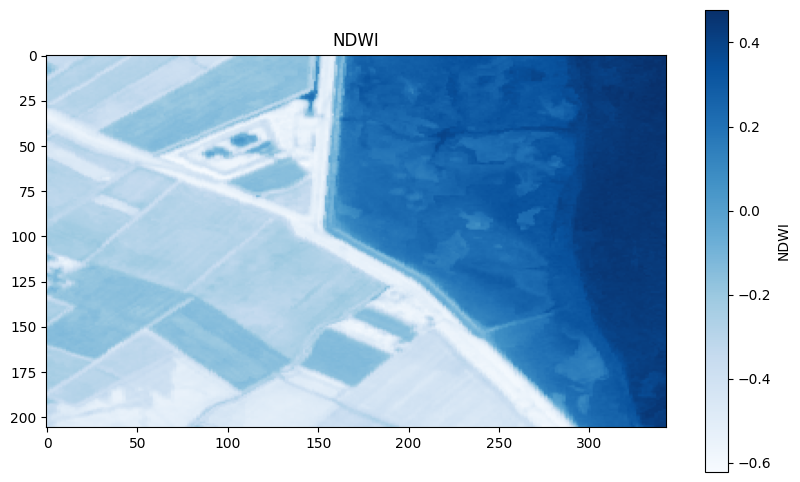

In [ ]:
with rasterio.open(ms_path) as ms:
    green = ms.read(2).astype('float32')  # Зеленый канал
    nir = ms.read(4).astype('float32')    # NIR канал

    ndwi = (green - nir) / (green + nir + 1e-10)

    plt.figure(figsize=(10,6))
    plt.title("NDWI")
    plt.imshow(ndwi, cmap='Blues')
    plt.colorbar(label="NDWI")
    plt.show()

    ndwi_meta = ms.meta.copy()
    ndwi_meta.update({
        "count": 1,
        "dtype": 'float32'
    })

    with rasterio.open("ndwi.tif", "w", **ndwi_meta) as dest:
        dest.write(ndwi, 1)

---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [ ]:
# Ваш код

2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [ ]:
# Ваш код

3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

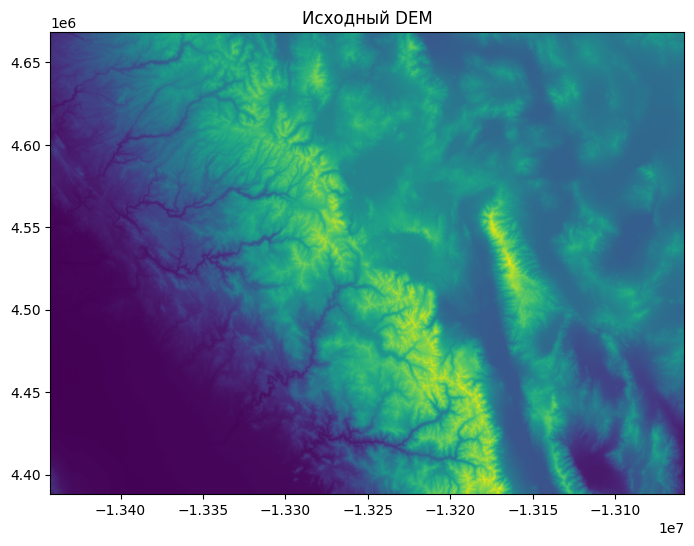

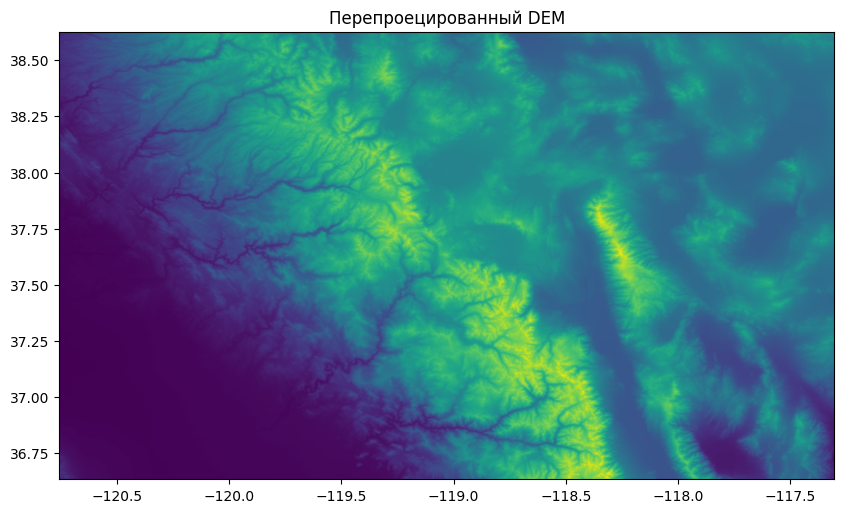

In [ ]:
dst_crs = 'EPSG:4326'
with rasterio.open(dem_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    reprojected_dem = np.empty((src.count, height, width), dtype=src.dtypes[0])

    for i in range(1, src.count + 1):
        reproject(
            source=rasterio.band(src, i),
            destination=reprojected_dem[i-1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    with rasterio.open("reprojected_dem.tif", "w", **kwargs) as dest:
        dest.write(reprojected_dem)

with rasterio.open(dem_path) as src:
    plt.figure(figsize=(10,6))
    plt.title("Исходный DEM")
    show(src)

with rasterio.open("reprojected_dem.tif") as src:
    plt.figure(figsize=(10,6))
    plt.title("Перепроецированный DEM")
    show(src)

---